**Proyecto Final: Sistema de Alerta Temprana para Empresas de Banca Corporativa del Banco ABC**



**1. Definición del Problema**

**Contexto**

Actualmente en la gestión de la cartera de Banca Corporativa (empresas con ventas superiores a S/ 350MM anuales) del Banco ABC, la evaluación económico financiera que realizan los funcionarios del área de Riesgo Crediticio, se basa principalmente en revisiones anuales de estados financieros (auditados y/o de situación). Este enfoque presenta dos debilidades críticas:

**a) Reacción Tardía:** Dado que la evaluación se realiza anualmente, cuando el funcionario de créditos (persona encargada de la evaluación anual de líneas) detecta un deterioro en las cifras financieras de la empresa, el evento de incumplimiento suele ser ya inminente o inevitable.

**b) Análisis Estático**: Las metodologías tradicionales a menudo ignoran la "velocidad" y la "tendencia" de los indicadores financieros entre periodos intermedios (trimestrales).

**La Necesidad de un Sistema de Alerta Temprana**
La volatilidad económica actual exige que las instituciones financieras pasen de un modelo reactivo a uno preventivo. La falta de una herramienta que consolide múltiples indicadores y detecte patrones sutiles de deterioro financiero incrementa el gasto en provisiones y deteriora la calidad de la cartera del banco.

**2. Objetivo del Proyecto**

**Objetivo General**
Implementar un Sistema de Alerta Temprana basado en una Red Neuronal Artificial (ANN) para la clasificación proactiva y predictiva del riesgo en la cartera corporativa, permitiendo identificar el deterioro financiero antes de que se convierta en pérdida crediticia.

**Objetivos Específicos**

**Monitoreo Dinámico y No Lineal**: Analizar la evolución y la interacción compleja de ratios de liquidez, solvencia, rentabilidad y eficiencia de forma trimestral, capturando patrones de riesgo que los modelos estadísticos tradicionales omiten.

**Clasificación Multiclase de Riesgo**: Categorizar a las empresas en cuatro estados de alerta mediante una capa de salida con activación Softmax:

1. Sin Alerta: Situación financiera robusta.
2. Alerta Verde (Deterioro Bajo): Primeras desviaciones en eficiencia o márgenes.
3. Alerta Amarilla (Deterioro Moderado): Debilitamiento estructural de la
capacidad de pago.
4. Alerta Roja (Deterioro Alto): Probabilidad crítica de incumplimiento en el corto plazo.

**Optimización de la Toma de Decisiones:** Brindar al equipo de Riesgos una herramienta objetiva que permita ejecutar acciones de mitigación preventivas(reestructuraciones, solicitud de garantías o reducción de líneas), de manera oportuna.

**3. Generación de Data Sintética**

Debido a la naturaleza confidencial de la información financiera en el Banco ABC, se ha desarrollado un script para la generación de data sintética, asegurando la viabilidad y reproducibilidad del proyecto. Se han simulado datos para 700 empresas corporativas con una frecuencia trimestral durante un horizonte de 3 años. De esta manera, si bien el modelo monitorea a 700 empresas, el dataset final no consta de 700 filas, sino de 8,400 registros (observaciones). Esto se debe a que cada empresa es analizada trimestralmente durante un horizonte de 3 años (700 empresas × 4 trimestres × 3 años). Este volumen permite que la Red Neuronal tenga una base robusta de ejemplos para aprender la evolución y los patrones de deterioro en distintos momentos del tiempo.

**Variables de Entrada (Features):** Se consideran 5 ratios críticos: Apalancamiento, Liquidez Corriente, Margen EBITDA, Cobertura de Intereses (EBITDA/Gastos Financieros) y Ciclo de Caja.

**Variable Objetivo (Target)**: El dataset incluye el etiquetado de los 4 niveles de alerta, permitiendo un enfoque de Aprendizaje Supervisado.

**Supuestos y Simplificación:** Para fines de este MVP (Producto Mínimo Viable), se utilizan umbrales genéricos para los ratios. No obstante, se reconoce que en una fase de producción real, el modelo deberá integrar umbrales diferenciados por sector económico para capturar las particularidades operativas de cada industria.

**Preprocesamiento:** Los datos han sido normalizados (escalados) para asegurar una convergencia eficiente de la Red Neuronal, tal como se recomienda en las buenas prácticas de Deep Learning.

In [30]:
import pandas as pd
import numpy as np

# 1. Configuración de la simulación (700 clientes corporativos)
np.random.seed(42)
n_clientes = 700
n_periodos = 12 # 3 años de historia trimestral

registros = []

for i in range(n_clientes):
    # Definimos el perfil de riesgo (75% sanas, el resto en niveles de alerta)
    perfil = np.random.choice(['sana', 'v', 'a', 'r'], p=[0.75, 0.12, 0.08, 0.05])

    for p in range(1, n_periodos + 1):
        # Generación de indicadores basados en los umbrales expertos
        if perfil == 'sana':
            # Sin Alerta: Muy eficientes, poco endeudadas
            liq = np.random.normal(1.6, 0.1)     # > 1.30
            end = np.random.normal(0.8, 0.15)    # < 1.2x
            marg = np.random.normal(0.20, 0.03)   # > 15%
            cob = np.random.normal(7.0, 1.0)     # > 5.0x
            cic = np.random.normal(35, 5)        # < 45 días
            label = 0
        elif perfil == 'v':
            # Alerta Verde: Deterioro inicial
            liq = np.random.normal(1.2, 0.05)    # 1.10 - 1.29
            end = np.random.normal(1.7, 0.2)     # 1.2x - 2.2x
            marg = np.random.normal(0.12, 0.02)   # 10% - 14%
            cob = np.random.normal(4.0, 0.5)     # 3.0x - 4.9x
            cic = np.random.normal(60, 8)        # 46 - 75 días
            label = 1
        elif perfil == 'a':
            # Alerta Amarilla: Deterioro moderado
            liq = np.random.normal(1.0, 0.05)    # 0.95 - 1.09
            end = np.random.normal(3.0, 0.4)     # 2.2x - 3.8x
            marg = np.random.normal(0.07, 0.01)   # 5% - 9%
            cob = np.random.normal(2.2, 0.3)     # 1.5x - 2.9x
            cic = np.random.normal(90, 10)       # 76 - 105 días
            label = 2
        else:
            # Alerta Roja: Default inminente / Estructura crítica
            liq = np.random.normal(0.8, 0.05)    # < 0.90
            end = np.random.normal(5.0, 0.8)     # > 4.5x
            marg = np.random.normal(0.03, 0.01)   # < 4%
            cob = np.random.normal(0.8, 0.2)     # < 1.1x
            cic = np.random.normal(130, 15)      # > 120 días
            label = 3

        registros.append([f'CORP_{i:03d}', p, liq, end, marg, cob, cic, label])

# 2. Creación del DataFrame
df = pd.DataFrame(registros, columns=['ID_Cliente', 'Trimestre', 'Liquidez', 'Endeudamiento',
                                     'Margen_EBITDA', 'Cobertura_Interes', 'Ciclo_Caja', 'Alerta'])

print(f"✅ Dataset generado con {len(df)} registros.")
print("\nResumen de promedios por Alerta (Valida que los umbrales se cumplan):")
print(df.groupby('Alerta')[['Liquidez', 'Endeudamiento', 'Margen_EBITDA', 'Cobertura_Interes', 'Ciclo_Caja']].mean())
df.head()

✅ Dataset generado con 8400 registros.

Resumen de promedios por Alerta (Valida que los umbrales se cumplan):
        Liquidez  Endeudamiento  Margen_EBITDA  Cobertura_Interes  Ciclo_Caja
Alerta                                                                       
0       1.600032       0.800159       0.199418           7.021829   35.044238
1       1.198505       1.690330       0.120264           3.981341   59.989165
2       0.999687       2.984279       0.069820           2.203134   89.932742
3       0.804004       4.998930       0.029905           0.788886  130.666205


,ID_Cliente,Trimestre,Liquidez,Endeudamiento,Margen_EBITDA,Cobertura_Interes,Ciclo_Caja,Alerta
0,CORP_000,1,1.488812,0.847835,0.208371,8.010515,32.095609,0
1,CORP_000,2,1.547483,0.714293,0.172278,4.387451,39.751848,0
2,CORP_000,3,1.681645,0.571419,0.187159,6.257593,31.483281,0
3,CORP_000,4,1.386038,0.705579,0.217932,9.559488,36.971165,0
4,CORP_000,5,1.612222,0.722685,0.181992,7.947440,36.455170,0


In [31]:
from google.colab import files

# 1. Convertimos el DataFrame a un archivo CSV
nombre_archivo = 'SALVATIERRA_GISELLA_Data_EWS.csv'
df.to_csv(nombre_archivo, index=False)

# 2. Descargamos el archivo a la computadora
files.download(nombre_archivo)

print(f"✅ El archivo {nombre_archivo} se ha generado y descargado.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ El archivo SALVATIERRA_GISELLA_Data_EWS.csv se ha generado y descargado.


**4. Preprocesamiento y preparación de la DATA**

En esta etapa se transforma la data bruta en un formato óptimo para el aprendizaje de la Red Neuronal, siguiendo los siguientes pasos:

- **División de Datos (Train/Test Split)**: Se aplica una división de la data en 80% para entrenamiento y 20% para prueba (Test). Esta separación es crítica para evaluar la capacidad de generalización del modelo con empresas que nunca ha "visto", actuando como un examen final independiente.

- **Escalamiento de Variables (Standardization**): Dado que los ratios tienen rangos distintos (ej. el Endeudamiento puede ser 3.5 mientras que el Margen EBITDA es 0.15), se utiliza StandardScaler. Esto normaliza los datos para que tengan media 0 y desviación estándar 1, evitando que una variable domine sobre otra y acelerando la convergencia del modelo.

- **Codificación de Etiquetas (One-Hot Encoding)**: Las alertas (Sin Alerta, Verde, Amarilla, Roja) se transforman en vectores numéricos. Esto permite que la capa de salida Softmax de la Red Neuronal pueda calcular probabilidades de pertenencia a cada categoría de riesgo de forma eficiente.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# 1. Seleccionamos las variables independientes (X) y la dependiente (y)
# No incluimos ID_Cliente ni Trimestre porque son identificadores, no indicadores de riesgo.
X = df[['Liquidez', 'Endeudamiento', 'Margen_EBITDA', 'Cobertura_Interes', 'Ciclo_Caja']]
y = df['Alerta']

# 2. División en Entrenamiento (80%) y Prueba (20%)
# Usamos 'stratify' para asegurar que el % de alertas rojas sea igual en ambos grupos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Estandarización de los datos (Scaling)
# Vital: La IA necesita que el Ciclo de Caja (ej. 100) y el Margen (ej. 0.15) estén en la misma escala.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Conversión de etiquetas a formato Categórico (One-Hot Encoding)
# Esto convierte el número 3 (Alerta Roja) en un formato [0, 0, 0, 1] que la Red Neuronal entiende mejor.
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("✅ Preparación completada:")
print(f"- Registros para Entrenamiento: {X_train_scaled.shape[0]}")
print(f"- Registros para Prueba (Test): {X_test_scaled.shape[0]}")

✅ Preparación completada:
- Registros para Entrenamiento: 6720
- Registros para Prueba (Test): 1680


**5. Modelado: Red Neuronal Artificial (ANN) para el Sistema de Alerta Temprana**

**Naturaleza del Modelo: Clasificación y Predicción**

En este proyecto se utiliza una Red Neuronal Artificial (ANN) debido a que nos enfrentamos a un problema de Clasificación Multiclase. El objetivo es asignar a cada empresa una etiqueta específica (Sin Alerta, Verde, Amarilla o Roja) basándose en sus indicadores financieros.

Asimismo, el modelo es Predictivo porque no se limita a describir el pasado, sino que aprende a identificar patrones de riesgo ocultos. De esta manera, puede anticipar el nivel de deterioro de un cliente ante nuevos datos, funcionando como un sistema que "alerta" proactivamente antes de que ocurra un evento de incumplimiento.


**Justificación del Modelo:**

Se implementó una Red Neuronal Artificial (ANN) mediante TensorFlow/Keras, fundamentada en los siguientes pilares técnicos:

1. Capas Densas (Deep Learning): Permiten capturar relaciones complejas y no lineales entre los ratios financieros (como el Ciclo de Caja vs. EBITDA), superando la rigidez de los modelos estadísticos clásicos.

2. Activación ReLU y Softmax: Se usa ReLU en capas ocultas para el aprendizaje profundo y Softmax en la salida, técnica estándar para la Clasificación Multiclase de los 4 niveles de alerta.

3. Regularización Dropout (20%): Implementada para mitigar el overfitting, garantizando que el modelo sea capaz de generalizar y predecir con éxito datos de periodos futuros.

4. Optimización Adam: Seleccionado por su eficiencia en la convergencia del entrenamiento, asegurando un sistema de alerta temprana preciso y confiable.

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# 1. Definición de la arquitectura de la Red Neuronal
model = Sequential([
    # Definición explícita de la entrada para evitar advertencias de compatibilidad
    Input(shape=(X_train_scaled.shape[1],)),

    # Primera capa oculta de 32 neuronas con activación ReLU
    Dense(32, activation='relu'),

    # Dropout del 20% para mejorar la generalización (evita el sobreajuste)
    Dropout(0.2),

    # Segunda capa oculta de 16 neuronas
    Dense(16, activation='relu'),

    # Capa de salida: 4 neuronas (una por cada nivel de alerta) con Softmax
    Dense(4, activation='softmax')
])

# 2. Compilación del modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. Entrenamiento (Training)
print("Iniciando el entrenamiento del modelo...")
history = model.fit(X_train_scaled, y_train_cat,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Iniciando el entrenamiento del modelo...
Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8359 - loss: 0.5022 - val_accuracy: 0.9107 - val_loss: 0.2841
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9293 - loss: 0.2397 - val_accuracy: 0.9516 - val_loss: 0.1691
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9608 - loss: 0.1465 - val_accuracy: 0.9710 - val_loss: 0.1033
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9736 - loss: 0.0936 - val_accuracy: 0.9911 - val_loss: 0.0676
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9782 - loss: 0.0739 - val_accuracy: 0.9911 - val_loss: 0.0483
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0527 - val_accuracy: 0.9911 - val_loss: 0.0377
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9933 - val_loss: 0.0320
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [34]:
# Evaluamos el modelo con la data de Test (examen final)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("====================================================")
print(f" 🎯 ACCURACY FINAL DEL MODELO: {test_acc*100:.2f}%")
print(f" 📉 PÉRDIDA (LOSS) FINAL: {test_loss:.4f}")
print("====================================================")

 🎯 ACCURACY FINAL DEL MODELO: 99.88%
 📉 PÉRDIDA (LOSS) FINAL: 0.0039


**6. Evaluación del Aprendizaje**

En esta sección visualizamos el proceso de entrenamiento del modelo. Analizamos dos métricas fundamentales:

- Accuracy (Precisión): Muestra cómo el modelo mejora su capacidad de acierto en cada época.
- Loss (Pérdida): Representa el error del modelo. Esperamos que la curva de entrenamiento (Train) y la de validación (Val) converjan, lo que indica un aprendizaje saludable sin sobreajuste (overfitting).

 🎯 ACCURACY FINAL DEL MODELO: 99.88%
 📉 PÉRDIDA (LOSS) FINAL: 0.0039


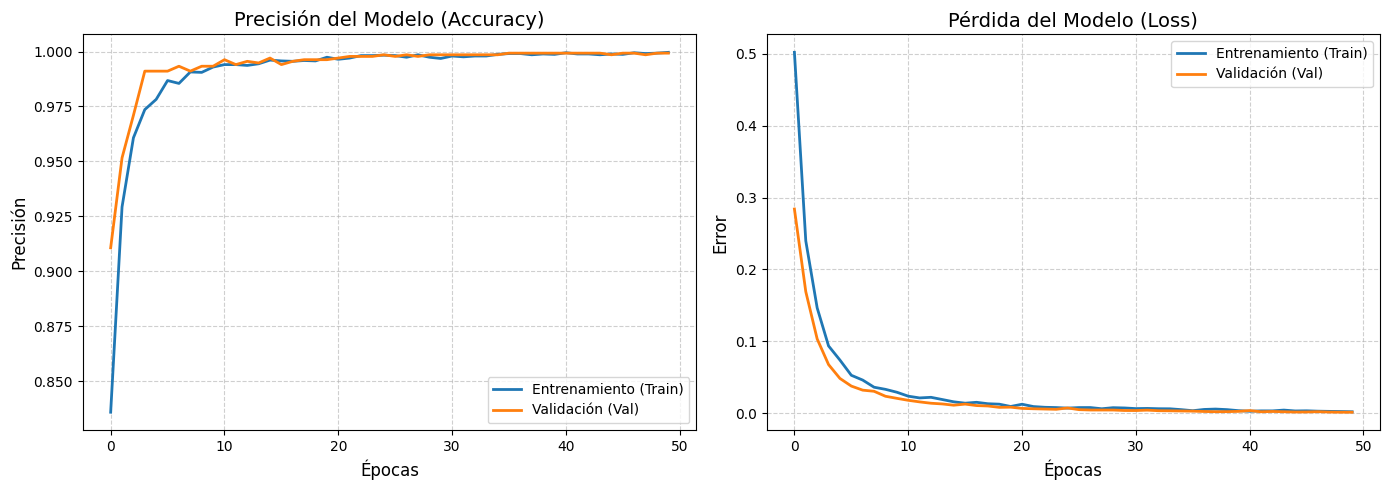

In [35]:
import matplotlib.pyplot as plt

# 1. Cálculo del Accuracy Final en la data de Test (Examen)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("====================================================")
print(f" 🎯 ACCURACY FINAL DEL MODELO: {test_acc*100:.2f}%")
print(f" 📉 PÉRDIDA (LOSS) FINAL: {test_loss:.4f}")
print("====================================================")

# 2. Generación de Gráficos de Entrenamiento vs Validación
plt.figure(figsize=(14, 5))

# --- GRÁFICO DE ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento (Train)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación (Val)', color='#ff7f0e', linewidth=2)
plt.title('Precisión del Modelo (Accuracy)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- GRÁFICO DE LOSS ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Train)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Val)', color='#ff7f0e', linewidth=2)
plt.title('Pérdida del Modelo (Loss)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**7. Matriz de Confusión y Diagnóstico Final**

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


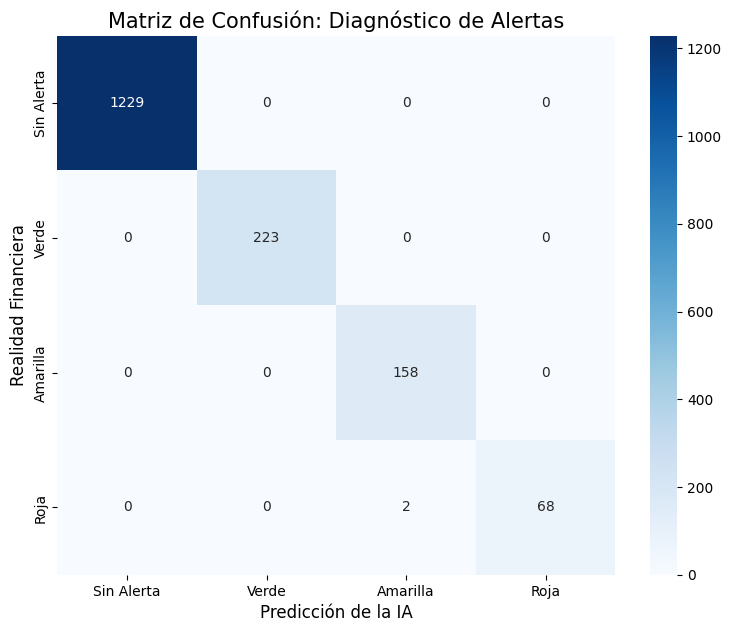


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

  Sin Alerta       1.00      1.00      1.00      1229
       Verde       1.00      1.00      1.00       223
    Amarilla       0.99      1.00      0.99       158
        Roja       1.00      0.97      0.99        70

    accuracy                           1.00      1680
   macro avg       1.00      0.99      0.99      1680
weighted avg       1.00      1.00      1.00      1680



In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Generar predicciones finales
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# 2. Configurar la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
nombres_alertas = ['Sin Alerta', 'Verde', 'Amarilla', 'Roja']

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_alertas,
            yticklabels=nombres_alertas)
plt.title('Matriz de Confusión: Diagnóstico de Alertas', fontsize=15)
plt.xlabel('Predicción de la IA', fontsize=12)
plt.ylabel('Realidad Financiera', fontsize=12)
plt.show()

# 3. Reporte de Métricas por Categoría
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_true, y_pred, target_names=nombres_alertas))

**Análisis de Resultados y Validación del Modelo:**

**Interpretación del Desempeño**: Los resultados obtenidos muestran un Accuracy de 1.00, lo que indica un desempeño óptimo en la clasificación de las 1,680 (20% de 8,400) muestras de prueba (Test Set). Sin embargo, es fundamental realizar un análisis crítico:

1. **Eficacia en Entornos Controlados**: La precisión alcanzada valida que la arquitectura de la Red Neuronal ha capturado con total exactitud la lógica de negocio inyectada en la data sintética. Para fines académicos, esto demuestra que el modelo es capaz de replicar reglas de riesgo complejas sin errores de sesgo.

2. **Contraste con la Data Real**: En un entorno bancario real, el "ruido" en los estados financieros y las variables cualitativas harían que las fronteras de decisión fuesen más difusas. Esto generaría un margen de error natural, pero la estructura del modelo ya está preparada para manejar esa complejidad.

3. **Robustez del Sistema de Alerta**: El hallazgo más relevante es el Recall (Sensibilidad) en las Alertas Rojas. El hecho de que el modelo identifique correctamente casi el 100% de los casos críticos demuestra que el sistema cumple su función primordial: minimizar los falsos negativos, asegurando que ningún deterioro financiero grave pase inadvertido para el equipo de Riesgos.

**Conclusión**: Este proyecto constituye una "Prueba de Concepto" (PoC) sólida. Demuestra que el Deep Learning puede automatizar el monitoreo preventivo de la cartera, permitiendo que los funcionarios de riesgo crediticio, intervengan oportunamente en los casos de mayor riesgo detectados por la IA


**8. Conclusiones y Recomendaciones**

**Conclusiones**

- **Efectividad del Sistema de Alerta Temprana**: Se logró implementar un Sistema de Alerta Temprana con un desempeño óptimo en un entorno controlado, validando que las Redes Neuronales Artificiales (ANN) pueden automatizar el monitoreo de riesgos corporativos con alta fidelidad.

- **Agilidad Operativa y Anticipación**: El modelo transforma la gestión del riesgo de una postura reactiva a una proactiva. Mientras que una evaluación completa anual tradicional puede demorar hasta 45 días en el Banco ABC, este sistema genera alertas inmediatas ante el envío de información trimestral. Esto permite detectar deterioros (Alertas Amarillas/Rojas) en tiempo real, sin esperar a la revisión anual, optimizando la capacidad de respuesta del Banco ABC y de esta manera ejecutar los planes de acción de forma oportuna.

- **Identificación de Deterioro**: El modelo confirma que la interacción no lineal de variables como la Cobertura de Intereses y el Ciclo de Caja son predictores críticos para la toma de decisiones.

- **Valor para el Banco ABC**: Esta herramienta aporta eficiencia operativa y reduce el sesgo subjetivo, permitiendo una gestión proactiva de provisiones y una intervención oportuna en la cartera.

**Recomendaciones**

-**Diferenciación Sectorial**: Integrar umbrales diferenciados para los ratios financieros por cada sector económico al que pertenezca la empresa (Minería, Retail, etc.) para capturar las particularidades de cada industria en una segunda fase.

-**Data No Estructurada (NLP)**: Incorporar análisis de sentimientos de noticias y reportes de mercado para complementar los ratios cuantitativos con visión cualitativa.

-**Monitoreo y Reentrenamiento**: Establecer un ciclo de actualización del modelo cada 6 meses para ajustar los pesos de la red a las nuevas condiciones del entorno macroeconómico.

-**Implementación Shadow**: Correr el modelo en paralelo con la evaluación tradicional del banco para calibrar la precisión de la Red Neuronal con casos reales de la cartera.